In [18]:
%load_ext autoreload

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from skimage.io import imread, imsave
from skimage import color, filters, exposure, morphology, measure, feature
from skimage.filters import rank
# optional: SciPy for some advanced operations
from scipy import ndimage as ndi

True
True


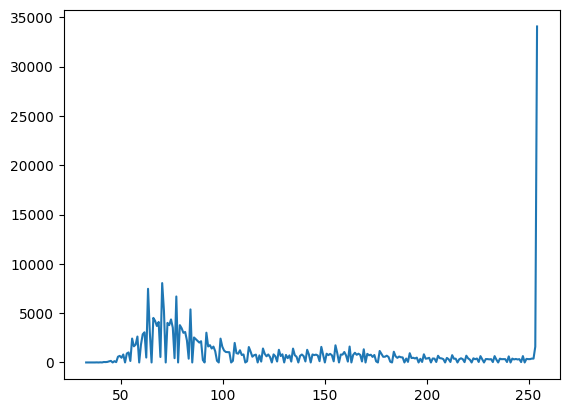

In [5]:
def histogram(image, bins=256):
    values = np.asarray(image).ravel()

    data_min = values.min()
    data_max = values.max()

    edges = np.linspace(data_min, data_max, bins + 1)

    if data_max == data_min:
        counts = np.zeros(bins, dtype=int)
        counts[0] = values.size
        return counts, edges

    scaled = (values - data_min) / (data_max - data_min) * bins
    indices = np.floor(scaled).astype(int)
    indices = np.clip(indices, 0, bins - 1)
    counts = np.bincount(indices, minlength=bins)

    return counts, edges

muscle = imread('../Images/muscle.jpg')
h_manual, edge_manual = histogram(muscle, bins=256)
h_numpy, edge_numpy = np.histogram(muscle, bins=256)

print(np.array_equal(h_manual, h_numpy))
print(np.allclose(edge_manual, edge_numpy))

plt.plot(edge_manual[:-1], h_manual)
plt.show()

In [9]:
cellules_corne = imread('C:\\Users\\Hippolyte\\Desktop\\TB Images\\Images\\cellules_cornee.jpg')
cellules_corne_2=np.array(cellules_corne)

In [14]:
v_max=cellules_corne_2.max()
v_min=cellules_corne_2.min()
a=255/(v_max-v_min)
b= - a*v_min
cellules_corne_grey=a*cellules_corne_2+b


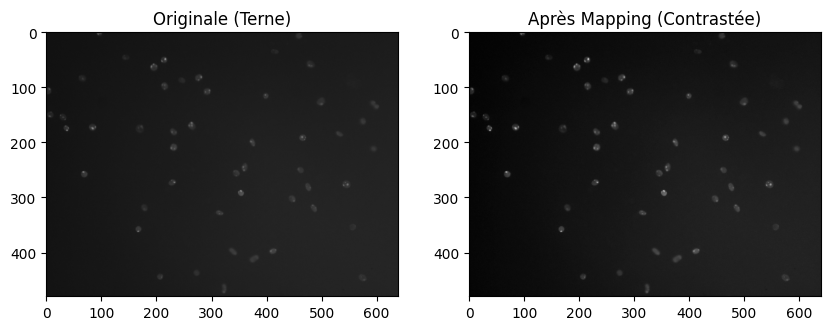

In [ ]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(cellules_corne_2, cmap='gray', vmin=0, vmax=255) 
plt.title("Originale (Terne)")

plt.subplot(1, 2, 2)
plt.imshow(cellules_corne_grey, cmap='gray', vmin=0, vmax=255)
plt.title("Après Mapping (Contrastée)")

plt.show()

1.5 Low pass filter

In [ ]:
blood=imread('C:\\Users\\Hippolyte\\Desktop\\TB Images\\Images\\blood.jpg')
print(np.shape(blood))
print(blood.dtype)


(265, 272)
uint8


In [42]:
moyen_blood=rank.mean(blood, morphology.disk(3))
median_blood=rank.median(blood, morphology.disk(3))
min_blood=rank.minimum(blood, morphology.disk(3))
max_blood=rank.maximum(blood, morphology.disk(3))
gaussian_blood=filters.gaussian(blood, sigma=1)

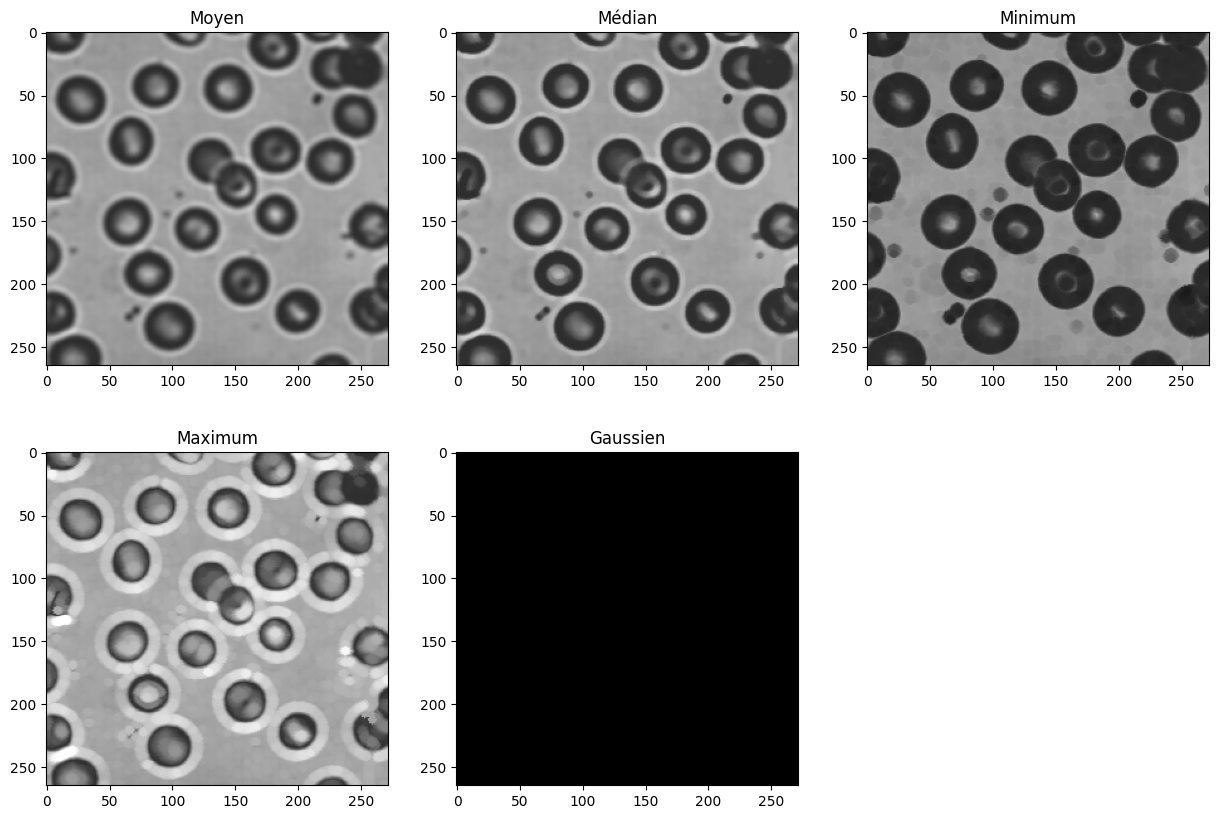

In [44]:
plt.figure(figsize=(15, 10))
plt.subplot(2, 3, 1)
plt.imshow(moyen_blood, cmap='gray', vmin=0, vmax=255)
plt.title("Moyen")
plt.subplot(2, 3, 2)
plt.imshow(median_blood, cmap='gray', vmin=0, vmax=255)
plt.title("Médian")
plt.subplot(2, 3, 3)
plt.imshow(min_blood, cmap='gray', vmin=0, vmax=255)
plt.title("Minimum")
plt.subplot(2, 3, 4)
plt.imshow(max_blood, cmap='gray', vmin=0, vmax=255)
plt.title("Maximum")
plt.subplot(2, 3, 5)
plt.imshow(gaussian_blood, cmap='gray', vmin=0, vmax=255)
plt.title("Gaussien")
plt.show()


Fourier Transform


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-3.141592653589793..3.141592653589793].


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-3.141592653589793..3.141592653589793].


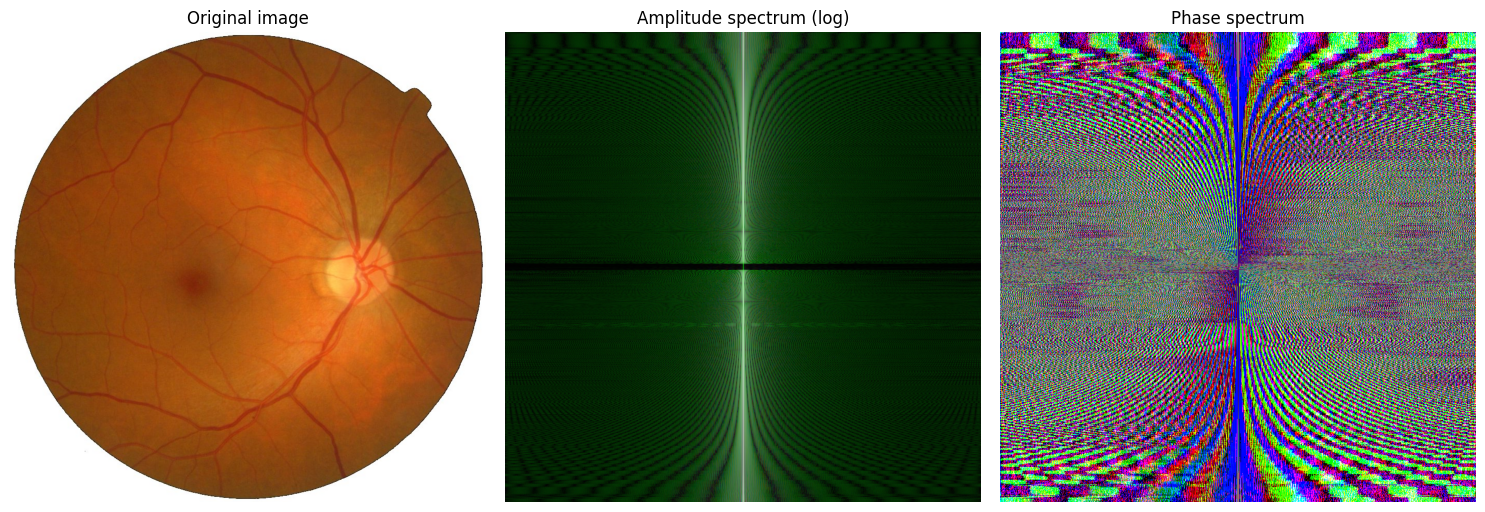

In [13]:
retine = imread('C:\\Users\\Hippolyte\\Desktop\\TB Images\\Images\\retine.png')


retine = retine.astype(np.float64)
if retine.max() > 1.0:
    retine /= 255.0

# Fourier transform of the image.
fft_retine = np.fft.fft2(retine)
fft_retine_shifted = np.fft.fftshift(fft_retine)

# Amplitude and phase of the spectrum.
amplitude = np.abs(fft_retine_shifted)
phase = np.angle(fft_retine_shifted)

# Log scale makes the amplitude easier to visualize.
amplitude_log = np.log1p(amplitude)
amplitude_display = (amplitude_log - amplitude_log.min()) / (amplitude_log.max() - amplitude_log.min())

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(retine, cmap='gray', vmin=0, vmax=1)
axes[0].set_title('Original image')
axes[0].axis('off')

axes[1].imshow(amplitude_display, cmap='gray', vmin=0, vmax=1)
axes[1].set_title('Amplitude spectrum (log)')
axes[1].axis('off')

axes[2].imshow(phase, cmap='twilight', vmin=-np.pi, vmax=np.pi)
axes[2].set_title('Phase spectrum')
axes[2].axis('off')

plt.tight_layout()
plt.show()

In [14]:
from skimage.data import camera
